In [2]:
# Import
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Business Understanding

Ziel: Vorhersage des Goldpreises für die nächsten h Tage

mit Forecast horizon h = {1,5,20}

Metriken: MSE, MAE, RMSE, MAPE 

# 2. Data understanding

In [3]:
# Gold Futures Ticker laden
gold = yf.Ticker("GC=F")

# Alle verfügbaren Daten seit Beginn der Dokumentation laden
df = gold.history(period="max", interval="1d")

# Prozentuale Veränderung zum Vortag berechnen
df["Change %"] = df["Close"].pct_change()

# Index (Datum) als Spalte zurückholen
df_prep = df.reset_index()

print(f"Erster Handelstag: {df_prep['Date'].min()}")
print(f"Letzter Handelstag: {df_prep['Date'].max()}")
print(f"Anzahl Datenpunkte: {len(df_prep)}")

Erster Handelstag: 2000-08-30 00:00:00-04:00
Letzter Handelstag: 2026-07-22 00:00:00-04:00
Anzahl Datenpunkte: 6496


In [4]:
# Head
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Change %
Date,,,,,,,,
2000-08-30 00:00:00-04:00,273.899994,273.899994,273.899994,273.899994,0,0.0,0.0,NaN
2000-08-31 00:00:00-04:00,274.799988,278.299988,274.799988,278.299988,0,0.0,0.0,0.016064
2000-09-01 00:00:00-04:00,277.000000,277.000000,277.000000,277.000000,0,0.0,0.0,-0.004671
2000-09-05 00:00:00-04:00,275.799988,275.799988,275.799988,275.799988,2,0.0,0.0,-0.004332
2000-09-06 00:00:00-04:00,274.200012,274.200012,274.200012,274.200012,0,0.0,0.0,-0.005801


In [5]:
# Describe
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Change %
count,6496.000000,6496.000000,6496.000000,6496.000000,6496.000000,6496.0,6496.0,6495.000000
mean,1323.259745,1330.482466,1315.716918,1323.218056,4273.932574,0.0,0.0,0.000482
std,871.602267,878.225797,864.405740,871.358769,23955.087401,0.0,0.0,0.011245
min,255.000000,256.100006,255.000000,255.100006,0.000000,0.0,0.0,-0.113662
25%,657.024979,659.074982,655.999985,656.700012,24.000000,0.0,0.0,-0.004843
50%,1256.199951,1262.250000,1251.149963,1255.850037,120.000000,0.0,0.0,0.000495
75%,1715.950012,1725.024994,1706.325043,1715.450043,463.250000,0.0,0.0,0.006393
max,5415.700195,5586.200195,5301.600098,5318.399902,386334.000000,0.0,0.0,0.090277


In [6]:
# Frequenz
import pandas as pd

freq = pd.infer_freq(df.index)
print(freq)  # z.B. 'D', 'H', 'M', 'MS', '5T', etc.

# -> none

# Zeitdifferenzen zwischen aufeinanderfolgenden Einträgen
diffs = df.index.to_series().diff().dropna()

# Häufigste Differenz = wahrscheinlichste Frequenz
print(diffs.value_counts())

# Nur die häufigste
print(diffs.mode()[0])

# -> weekday

None
Date
1 days 00:00:00    5087
3 days 00:00:00    1110
4 days 00:00:00     178
2 days 00:00:00      56
3 days 01:00:00      26
2 days 23:00:00      26
5 days 00:00:00      12
Name: count, dtype: int64
1 days 00:00:00


In [7]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6496 entries, 2000-08-30 00:00:00-04:00 to 2026-07-22 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          6496 non-null   float64
 1   High          6496 non-null   float64
 2   Low           6496 non-null   float64
 3   Close         6496 non-null   float64
 4   Volume        6496 non-null   int64  
 5   Dividends     6496 non-null   float64
 6   Stock Splits  6496 non-null   float64
 7   Change %      6495 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 456.8 KB


In [8]:
# Cut to relevant columns
df = df["Close"]
df.head()

Date
2000-08-30 00:00:00-04:00    273.899994
2000-08-31 00:00:00-04:00    278.299988
2000-09-01 00:00:00-04:00    277.000000
2000-09-05 00:00:00-04:00    275.799988
2000-09-06 00:00:00-04:00    274.200012
Name: Close, dtype: float64

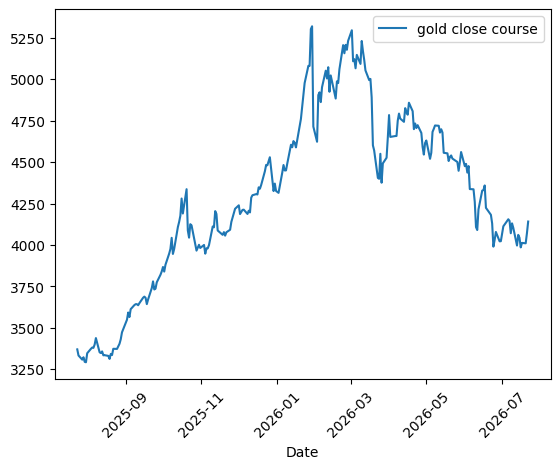

In [9]:
# Plot last 250 days

plt.figure()
plt.plot(df.tail(250),label="gold close course")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.legend()


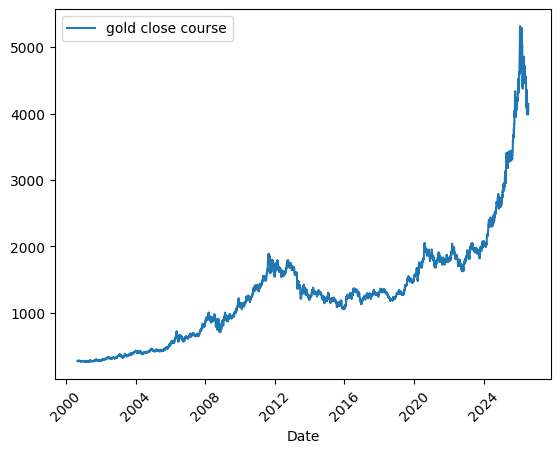

In [10]:
# Plot whole course

plt.figure()
plt.plot(df,label="gold close course")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.legend()

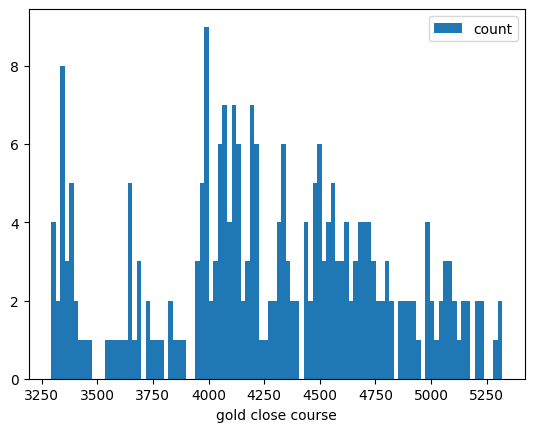

In [11]:
# histogramm of the last 250 days

plt.figure()
plt.hist(df.tail(250),bins=100,label="count")
plt.xlabel("gold close course")
plt.legend()


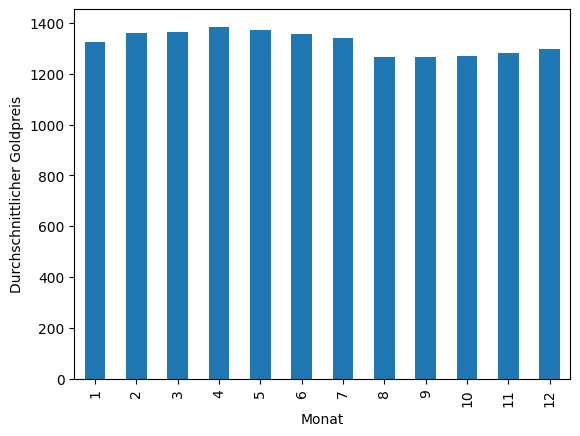

Date
1    1326.104740
2    1359.858834
3    1364.319613
4    1383.278995
5    1370.352362
Name: Close, dtype: float64

In [12]:
# durchschnittlicher Monatskurs
monthly = df.groupby(df.index.month).mean()

monthly.plot(kind="bar")
plt.xlabel("Monat")
plt.ylabel("Durchschnittlicher Goldpreis")
plt.show()

monthly.head()

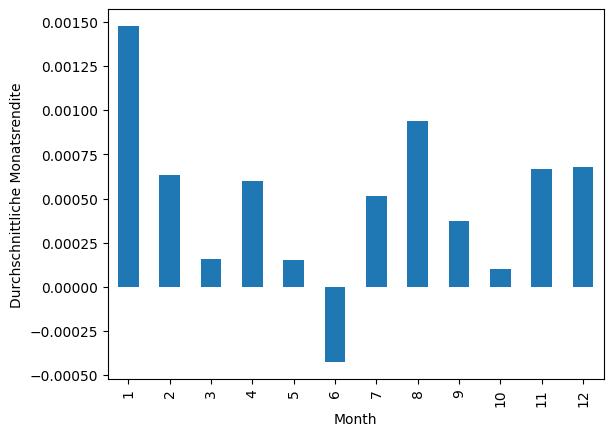

In [13]:
# durchschnittliche Monatsrenditen
returns = df.pct_change().dropna()

monthly_returns = returns.groupby(returns.index.month).mean()

monthly_returns.plot(kind="bar")
plt.ylabel("Durchschnittliche Monatsrendite")
plt.xlabel("Month")
plt.show()


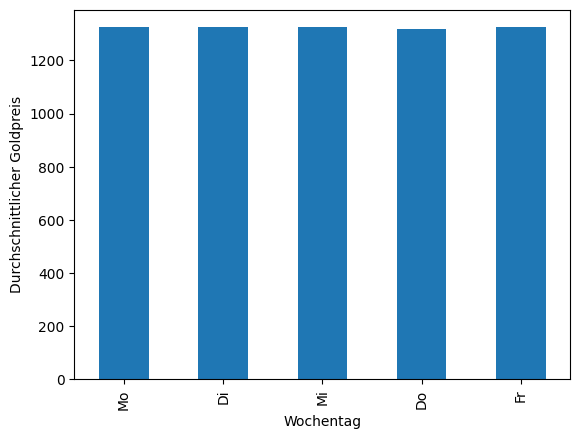

Mo    1324.001972
Di    1324.738264
Mi    1324.180525
Do    1318.488167
Fr    1324.702005
Name: Close, dtype: float64

In [14]:
# durchschnittlicher Tageskurs
weekday = df.groupby(df.index.day_of_week).mean()
weekday.index = [
    "Mo","Di","Mi","Do","Fr"
]

weekday.plot(kind="bar")
plt.xlabel("Wochentag")
plt.ylabel("Durchschnittlicher Goldpreis")
plt.show()

weekday.head()

<Axes: >

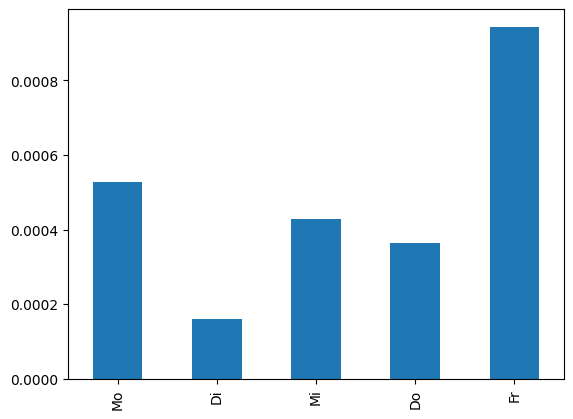

In [15]:
# Durchschnittlicher Rendite nach Wochentag

weekday_returns = returns.groupby(returns.index.dayofweek).mean()

weekday_returns.index = [
    "Mo","Di","Mi","Do","Fr"
]

weekday_returns.plot(kind="bar")

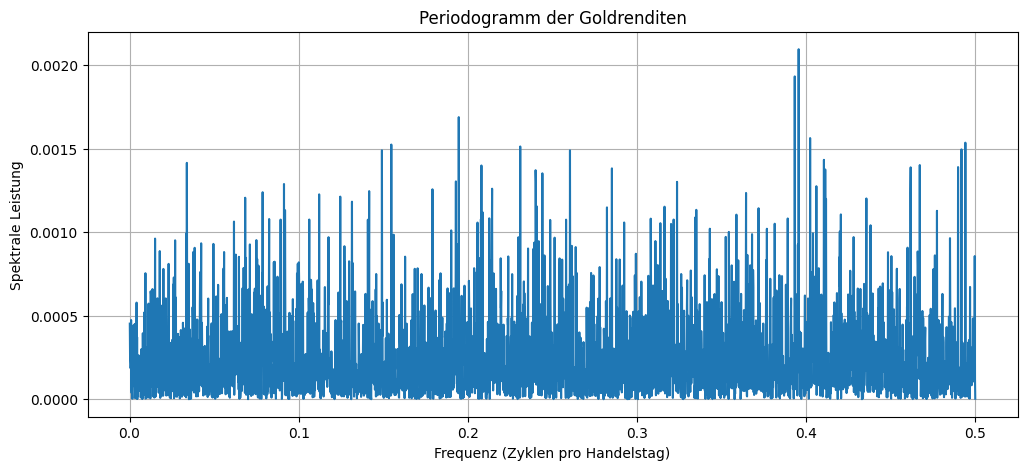

In [16]:
from scipy.signal import periodogram
import matplotlib.pyplot as plt

# Periodogramm berechnen
freqs, power = periodogram(returns)

# Frequenz = 0 entfernen (DC-Komponente)
freqs = freqs[1:]
power = power[1:]

# Plot
plt.figure(figsize=(12, 5))
plt.plot(freqs, power)
plt.title("Periodogramm der Goldrenditen")
plt.xlabel("Frequenz (Zyklen pro Handelstag)")
plt.ylabel("Spektrale Leistung")
plt.grid(True)
plt.show()


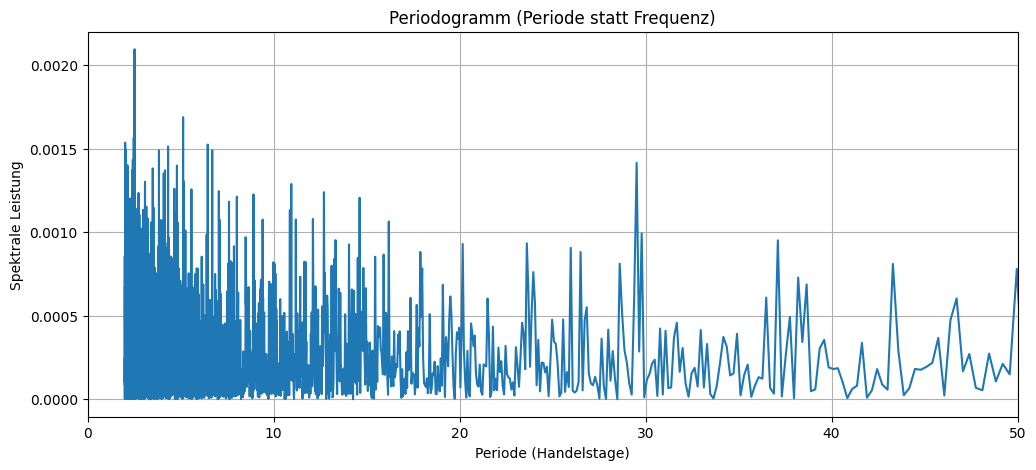

In [17]:
import numpy as np

periods = 1 / freqs

plt.figure(figsize=(12, 5))
plt.plot(periods, power)
plt.xlim(0, 50)          # nur Perioden bis 300 Handelstage anzeigen
plt.xlabel("Periode (Handelstage)")
plt.ylabel("Spektrale Leistung")
plt.title("Periodogramm (Periode statt Frequenz)")
plt.grid(True)
plt.show()

In [18]:
import pandas as pd

spectrum = pd.DataFrame({
    "Periode": periods,
    "Leistung": power
})

# größte Peaks
display(spectrum.nlargest(10, "Leistung"))

,Periode,Leistung
2568,2.528221,0.002095
2553,2.543070,0.001933
1263,5.138449,0.001689
2612,2.485649,0.001563
3208,2.023995,0.001536
1004,6.462687,0.001525
1499,4.330000,0.001513
3193,2.033500,0.001496
968,6.702786,0.001490
1690,3.840923,0.001490


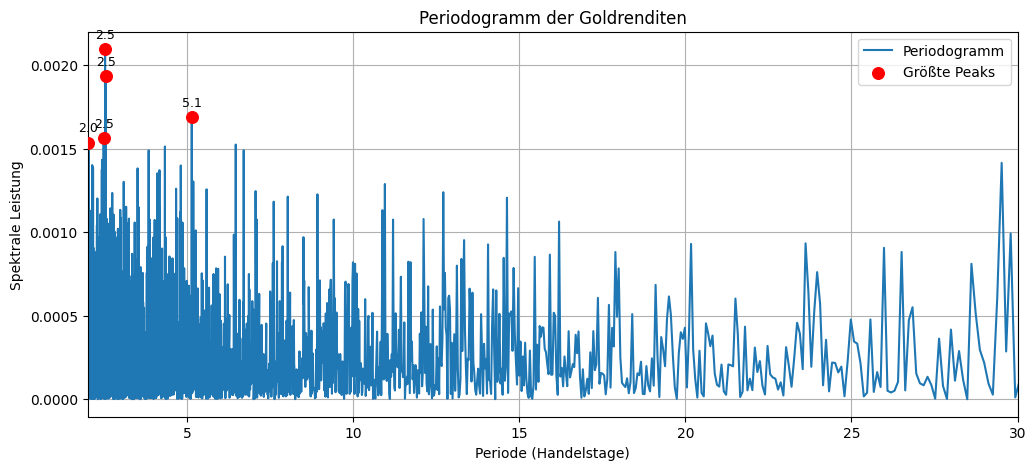

In [19]:
from scipy.signal import periodogram, find_peaks
import matplotlib.pyplot as plt
import numpy as np

freqs, power = periodogram(returns)

# Frequenz = 0 entfernen
freqs = freqs[1:]
power = power[1:]
periods = 1 / freqs

# Lokale Peaks finden
peaks, _ = find_peaks(power)

# Die 5 höchsten Peaks auswählen
n_peaks = 5
largest_peaks = peaks[np.argsort(power[peaks])[-n_peaks:]]

# Plot
plt.figure(figsize=(12,5))
plt.plot(periods, power, label="Periodogramm")
plt.scatter(periods[largest_peaks],
            power[largest_peaks],
            color="red",
            s=70,
            zorder=5,
            label="Größte Peaks")

# Peak-Werte beschriften
for i in largest_peaks:
    plt.annotate(f"{periods[i]:.1f}",
                 (periods[i], power[i]),
                 xytext=(0,8),
                 textcoords="offset points",
                 ha="center",
                 fontsize=9)

plt.xlim(2,30) # Nyquist-Frequenz
plt.xlabel("Periode (Handelstage)")
plt.ylabel("Spektrale Leistung")
plt.title("Periodogramm der Goldrenditen")
plt.grid(True)
plt.legend()
plt.show()

In [29]:
# Using STL to eventually find seasonality

from statsmodels.tsa.seasonal import STL
import ipywidgets as widgets
from IPython.display import display, clear_output

def plot_stl(period=12, seasonal=13, trend=21, robust=True):
    clear_output(wait=True)

    # STL benötigt ungerade Werte für seasonal und trend
    if seasonal % 2 == 0:
        seasonal += 1
    if trend % 2 == 0:
        trend += 1

    result = STL(
        df.tail(200),
        period=period,
        seasonal=seasonal,
        trend=trend,
        robust=robust
    ).fit()

    fig = result.plot()
    fig.set_size_inches(10, 8)
    plt.suptitle(
        f"STL-Zerlegung: period={period}, seasonal={seasonal}, trend={trend}, robust={robust}",
        y=1.02
    )
    plt.show()


period_slider = widgets.IntSlider(
    value=12,
    min=2,
    max=52,
    step=1,
    description="period"
)

seasonal_slider = widgets.IntSlider(
    value=13,
    min=7,
    max=51,
    step=2,
    description="seasonal"
)

trend_slider = widgets.IntSlider(
    value=21,
    min=7,
    max=101,
    step=2,
    description="trend"
)

robust_checkbox = widgets.Checkbox(
    value=True,
    description="robust"
)

ui = widgets.VBox([
    period_slider,
    seasonal_slider,
    trend_slider,
    robust_checkbox,
])

out = widgets.interactive_output(
    plot_stl,
    {
        "period": period_slider,
        "seasonal": seasonal_slider,
        "trend": trend_slider,
        "robust": robust_checkbox
    }
)

display(ui, out)

Output()

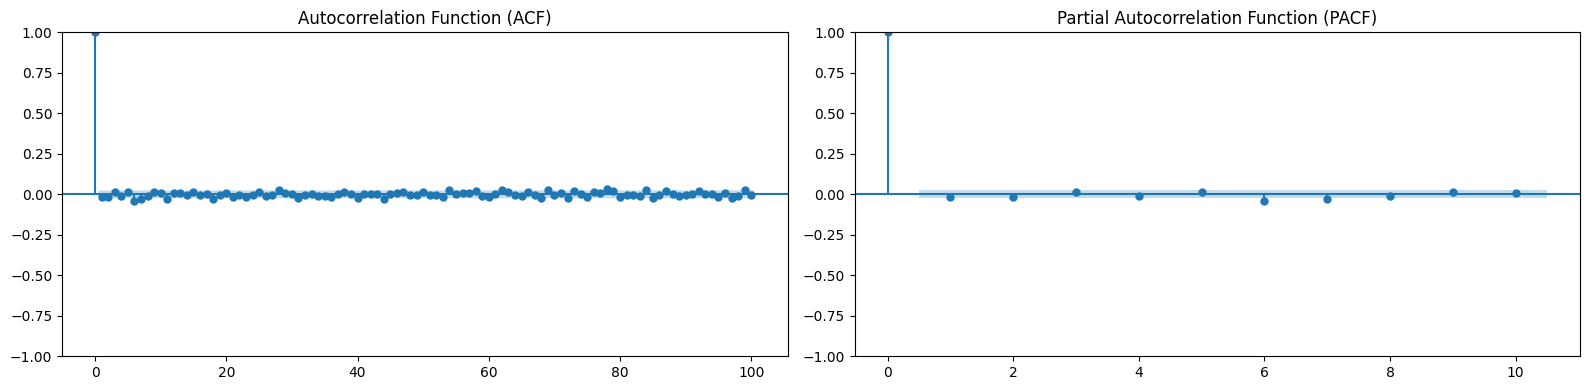

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF for the differenced series
# 
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
# ACF plot
plot_acf(returns.dropna(), lags=100, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# PACF plot
plot_pacf(returns.dropna(), lags=10, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

# Ausgangszeitreihe
ts = df.copy()

d = 0
max_d = 5

while d <= max_d:

    # ADF-Test
    adf_stat, adf_p, *_ = adfuller(ts)

    # KPSS-Test
    kpss_stat, kpss_p, *_ = kpss(ts, regression="c", nlags="auto")

    print(f"\nDifferenzierungsgrad d = {d}")
    print(f"ADF : p = {adf_p:.4f}")
    print(f"KPSS: p = {kpss_p:.4f}")

    # Stationär?
    if adf_p < 0.05 and kpss_p > 0.05:
        print("\n✓ Zeitreihe ist stationär.")
        break

    # Noch nicht stationär -> weiter differenzieren
    ts = ts.diff().dropna()
    d += 1

if d > max_d:
    print("\nAuch nach", max_d, "Differenzierungen keine eindeutige Stationarität.")
else:
    print(f"\nBenötigter Differenzierungsgrad: d = {d}")

C:\Users\fschm\AppData\Local\Temp\ipykernel_27644\1994421012.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(ts, regression="c", nlags="auto")



Differenzierungsgrad d = 0
ADF : p = 0.9942
KPSS: p = 0.0100

Differenzierungsgrad d = 1
ADF : p = 0.0000
KPSS: p = 0.0507

✓ Zeitreihe ist stationär.

Benötigter Differenzierungsgrad: d = 1


In [23]:
# Train-/Test-Split

# Train-/Val-/Test-Split

df_train = df.loc[:'2024-12-31']
df_val   = df.loc['2025-01-01':'2025-12-31']
df_test  = df.loc['2026-01-01':]

print(f"Training:    {df_train.index.min().date()} - {df_train.index.max().date()} ({len(df_train)} Beobachtungen)")
print(f"Validierung: {df_val.index.min().date()} - {df_val.index.max().date()} ({len(df_val)} Beobachtungen)")
print(f"Test:        {df_test.index.min().date()} - {df_test.index.max().date()} ({len(df_test)} Beobachtungen)")

Training:    2000-08-30 - 2024-12-31 (6106 Beobachtungen)
Validierung: 2025-01-02 - 2025-12-31 (252 Beobachtungen)
Test:        2026-01-02 - 2026-07-22 (138 Beobachtungen)


In [24]:
# Auto Arima

import warnings
import numpy as np
import pandas as pd

from pmdarima import auto_arima
from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Train Dataset

model = auto_arima(
    df_train,
    seasonal=False,   # keine Saisonalität
    trace=True,       # zeigt getestete Modelle
    stepwise=False,
    suppress_warnings=True
)

# Gefundenes Modell
print(model.summary())


 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=49285.598, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=49284.141, Time=0.40 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=49285.189, Time=0.85 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=49285.494, Time=1.30 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : AIC=49286.100, Time=1.85 sec
 ARIMA(0,1,5)(0,0,0)[0] intercept   : AIC=49288.090, Time=2.22 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=49284.231, Time=0.34 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=49285.670, Time=1.60 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=49281.090, Time=2.35 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=49282.751, Time=3.63 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : AIC=49288.092, Time=1.84 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=49285.098, Time=0.31 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=49280.960, Time=3.01 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=49282.695, Time=4.43 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=49281.343, Time=4.81

In [25]:
import warnings
import numpy as np
import pandas as pd

from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

def walk_forward_arima_multistep(
    train_data,
    val_data,
    order,
    horizon
):
    history = list(np.asarray(train_data, dtype=float))
    validation = np.asarray(val_data, dtype=float)

    all_predictions = []
    all_actuals = []

    # Es muss jeweils noch ein vollständiges Forecast-Fenster vorhanden sein
    n_origins = len(validation) - horizon + 1

    for i in range(n_origins):

        model = ARIMA(history, order=order)
        fitted_model = model.fit()

        # Forecast für t+1 bis t+horizon
        forecast = fitted_model.forecast(steps=horizon)
        forecast = np.asarray(forecast, dtype=float)

        # Zugehörige tatsächliche Werte
        actual_window = validation[i:i + horizon]

        all_predictions.append(forecast)
        all_actuals.append(actual_window)

        # Nur die nächste tatsächlich beobachtete Information wird ergänzt
        history.append(float(validation[i]))

    return (
        np.asarray(all_predictions),
        np.asarray(all_actuals)
    )

y_train = df_train.dropna().astype(float)
y_val = df_val.dropna().astype(float)
y_test = df_test.dropna().astype(float)

print("Training:", len(y_train))
print("Validierung:", len(y_val))
print("Test:", len(y_test))

# Parameter für Grid-Search definieren
p_values = range(0, 1)
q_values = range(0, 1)

d = 1

forecast_horizons = [1, 5, 20]

results = []

warnings.filterwarnings("ignore")

for horizon in forecast_horizons:

    print(f"\n{'=' * 60}")
    print(f"Forecast-Horizont: {horizon}")
    print(f"{'=' * 60}")

    for p, q in product(p_values, q_values):

        order = (p, d, q)

        try:
            predictions, actuals = walk_forward_arima_multistep(
                train_data=y_train,
                val_data=y_val,
                order=order,
                horizon=horizon
            )

            # Alle Prognosefenster und Forecast-Schritte zusammenführen
            predictions_flat = predictions.ravel()
            actuals_flat = actuals.ravel()

            mae = mean_absolute_error(
                actuals_flat,
                predictions_flat
            )

            mse = mean_squared_error(
                actuals_flat,
                predictions_flat
            )

            rmse = np.sqrt(mse)

            mape = mean_absolute_percentage_error(
                actuals_flat,
                predictions_flat
            ) * 100

            results.append({
                "order": order,
                "p": p,
                "d": d,
                "q": q,
                "horizon": horizon,
                "MAE": mae,
                "MSE": mse,
                "RMSE": rmse,
                "MAPE": mape,
                "forecast_origins": predictions.shape[0],
                "evaluated_predictions": predictions_flat.size
            })

            print(
                f"ARIMA{order}, H={horizon}: "
                f"MAE={mae:.4f}, "
                f"MSE={mse:.4f}, "
                f"RMSE={rmse:.4f}, "
                f"MAPE={mape:.4f}%"
            )

        except Exception as error:
            print(
                f"ARIMA{order}, H={horizon} "
                f"fehlgeschlagen: {error}"
            )


results_df = (
    pd.DataFrame(results)
    .sort_values(["horizon", "RMSE"])
    .reset_index(drop=True)
)

results_df

best_models = (
    results_df
    .sort_values("RMSE")
    .groupby("horizon", as_index=False)
    .first()
)

best_models[
    ["horizon", "order", "MAE", "MSE", "RMSE", "MAPE"]
]

Training: 6106
Validierung: 252
Test: 138

Forecast-Horizont: 1
ARIMA(0, 1, 0), H=1: MAE=33.5714, MSE=2241.7695, RMSE=47.3473, MAPE=0.9593%

Forecast-Horizont: 5
ARIMA(0, 1, 0), H=5: MAE=56.5994, MSE=5924.5370, RMSE=76.9710, MAPE=1.6156%

Forecast-Horizont: 20
ARIMA(0, 1, 0), H=20: MAE=104.5307, MSE=20141.2163, RMSE=141.9198, MAPE=2.9644%


,horizon,order,MAE,MSE,RMSE,MAPE
0,1,"(0, 1, 0)",33.571430,2241.769487,47.347328,0.959310
1,5,"(0, 1, 0)",56.599353,5924.536963,76.971014,1.615629
2,20,"(0, 1, 0)",104.530711,20141.216291,141.919753,2.964361


In [26]:
import ast
import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA


# Train- und Validierungsdaten zusammenführen
y_train_val = pd.concat([
    pd.Series(y_train),
    pd.Series(y_val)
]).dropna().astype(float)


def convert_order(order):
    """
    Stellt sicher, dass die ARIMA-Ordnung ein Tupel ist.

    Funktioniert für:
    (1, 1, 2)
    und
    "(1, 1, 2)"
    """
    if isinstance(order, str):
        order = ast.literal_eval(order)

    return tuple(int(value) for value in order)


# Hier werden die drei gefitteten Modelle gespeichert
fitted_best_models = {}

for _, row in best_models.iterrows():

    horizon = int(row["horizon"])
    order = convert_order(row["order"])

    model = ARIMA(
        y_train_val.to_numpy(),
        order=order
    )

    fitted_model = model.fit()

    fitted_best_models[horizon] = {
        "order": order,
        "model": fitted_model
    }

    print(
        f"ARIMA{order} für Horizont {horizon} "
        f"auf Train + Val gefittet."
    )

ARIMA(0, 1, 0) für Horizont 1 auf Train + Val gefittet.
ARIMA(0, 1, 0) für Horizont 5 auf Train + Val gefittet.
ARIMA(0, 1, 0) für Horizont 20 auf Train + Val gefittet.


In [27]:
def walk_forward_arima_test_multistep(
    train_val_data,
    test_data,
    order,
    horizon
):
    """
    Expanding-Window-Walk-Forward-Test.

    Liefert:
    - ARIMA-Prognosen
    - naive Prognosen
    - tatsächliche Werte
    """

    history = list(np.asarray(train_val_data, dtype=float))
    test = np.asarray(test_data, dtype=float)

    arima_predictions = []
    naive_predictions = []
    actuals = []

    n_origins = len(test) - horizon + 1

    for i in range(n_origins):

        model = ARIMA(history, order=order)
        fitted_model = model.fit()

        # ARIMA-Prognose
        arima_forecast = np.asarray(
            fitted_model.forecast(steps=horizon),
            dtype=float
        )

        # Naive Prognose:
        # letzter bekannter Wert über gesamten Horizont
        naive_forecast = np.repeat(
            history[-1],
            horizon
        )

        actual_window = test[i:i+horizon]

        arima_predictions.append(arima_forecast)
        naive_predictions.append(naive_forecast)
        actuals.append(actual_window)

        # nur nächste Beobachtung ergänzen
        history.append(float(test[i]))

    return (
        np.asarray(arima_predictions),
        np.asarray(naive_predictions),
        np.asarray(actuals)
    )

In [28]:
test_results = []

for _, row in best_models.iterrows():

    horizon = int(row["horizon"])
    order = convert_order(row["order"])

    arima_pred, naive_pred, actuals = walk_forward_arima_test_multistep(
        train_val_data=y_train_val,
        test_data=y_test,
        order=order,
        horizon=horizon
    )

    arima_flat = arima_pred.ravel()
    naive_flat = naive_pred.ravel()
    actuals_flat = actuals.ravel()

    arima_rmse = np.sqrt(
        mean_squared_error(actuals_flat, arima_flat)
    )

    naive_rmse = np.sqrt(
        mean_squared_error(actuals_flat, naive_flat)
    )

    test_results.append({

    "horizon": horizon,
    "order": order,

    "ARIMA_MAE": mean_absolute_error(
        actuals_flat,
        arima_flat
    ),

    "Naive_MAE": mean_absolute_error(
        actuals_flat,
        naive_flat
    ),

    "ARIMA_MSE": mean_squared_error(
        actuals_flat,
        arima_flat
    ),

    "Naive_MSE": mean_squared_error(
        actuals_flat,
        naive_flat
    ),

    "ARIMA_RMSE": arima_rmse,
    "Naive_RMSE": naive_rmse,

    "ARIMA_MAPE": mean_absolute_percentage_error(
        actuals_flat,
        arima_flat
    ) * 100,

    "Naive_MAPE": mean_absolute_percentage_error(
        actuals_flat,
        naive_flat
    ) * 100,

    "forecast_origins": arima_pred.shape[0],
    "evaluated_predictions": arima_pred.size,

    # Für die Visualisierung speichern
    "arima_predictions": arima_pred,
    "naive_predictions": naive_pred,
    "actuals": actuals
})

test_results_df = pd.DataFrame(test_results)

test_results_df

KeyboardInterrupt: 

In [ ]:
test_results_df = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key not in [
            "arima_predictions",
            "naive_predictions",
            "actuals"
        ]
    }
    for result in test_results
])

test_results_df

,horizon,order,ARIMA_MAE,Naive_MAE,ARIMA_MSE,Naive_MSE,ARIMA_RMSE,Naive_RMSE,ARIMA_MAPE,Naive_MAPE,forecast_origins,evaluated_predictions
0,1,"(0, 1, 0)",69.092763,69.092763,9799.870637,9799.870637,98.994296,98.994296,1.490485,1.490485,138,138
1,5,"(0, 1, 0)",118.194485,118.194485,26558.716241,26558.716241,162.968452,162.968452,2.547431,2.547431,134,670
2,20,"(0, 1, 0)",213.670761,213.670761,78588.128498,78588.128498,280.335742,280.335742,4.612368,4.612368,119,2380


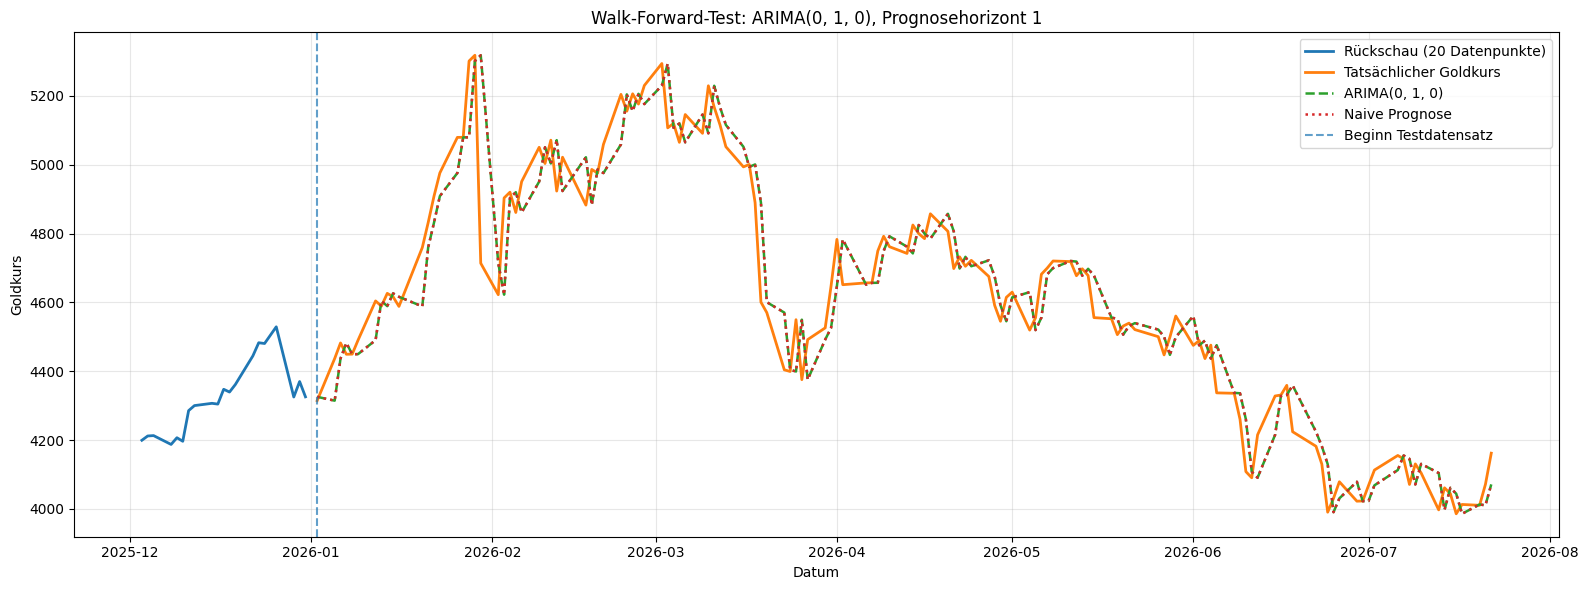

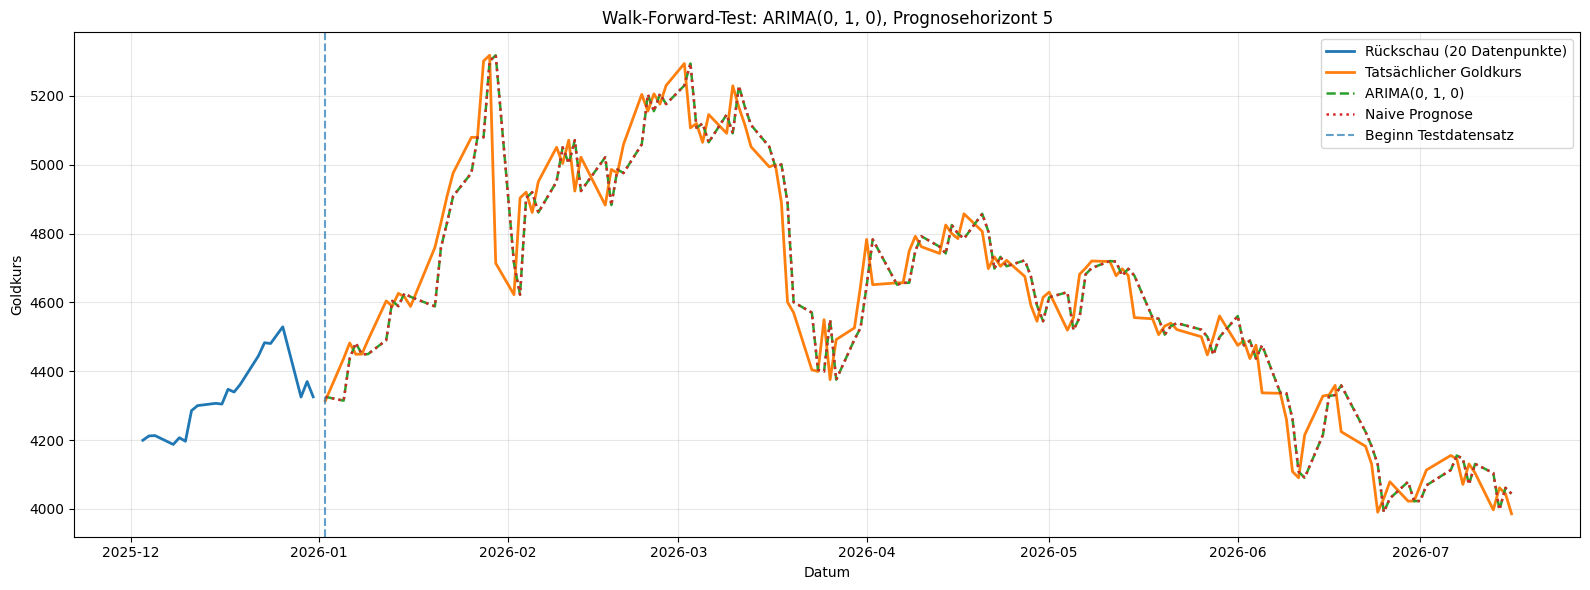

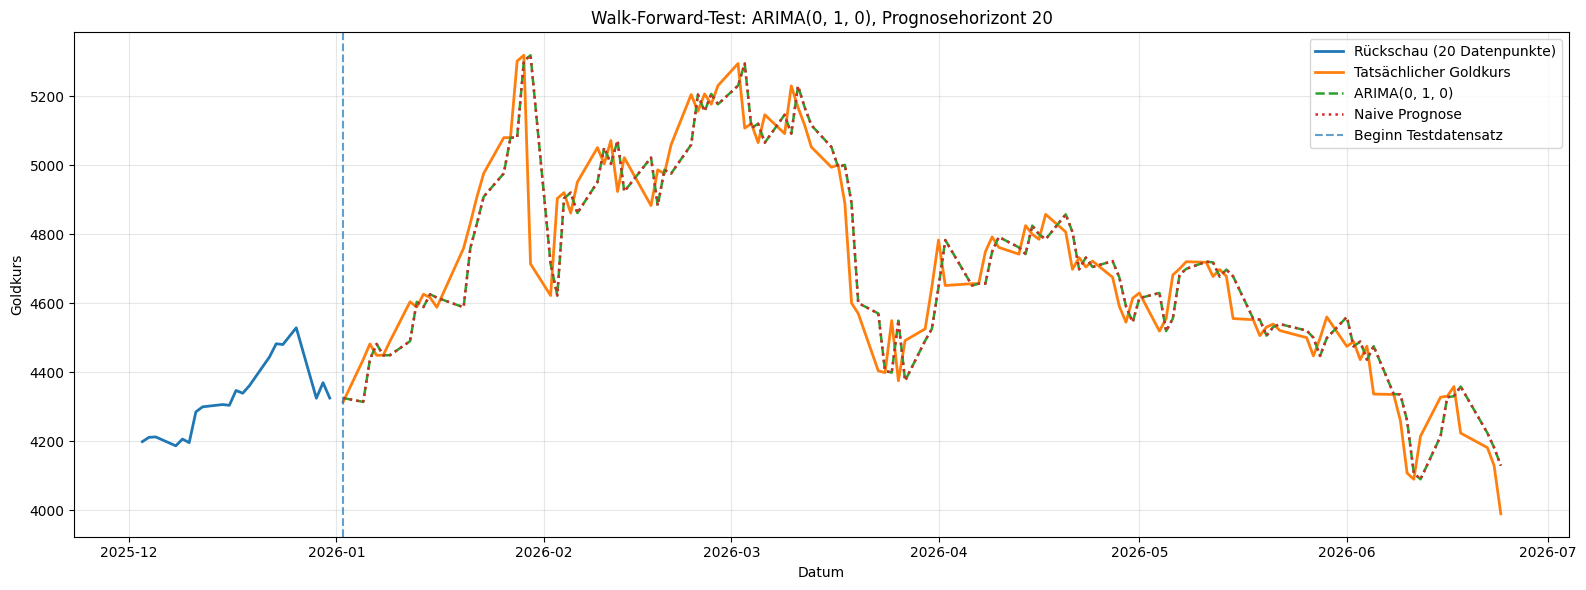

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_walk_forward_test(
    test_results,
    y_train_val,
    y_test,
    lookback=20
):
    """
    Visualisiert die Walk-Forward-Prognosen über den gesamten Testdatensatz.

    Pro Forecast-Ursprung wird die 1-Schritt-Prognose verwendet.
    Vor dem Testzeitraum werden die letzten 'lookback' Trainingswerte gezeigt.
    """

    # Sicherstellen, dass Series verwendet werden
    y_train_val = pd.Series(y_train_val).copy()
    y_test = pd.Series(y_test).copy()

    # Letzte Werte vor Beginn des Testdatensatzes
    history = y_train_val.iloc[-lookback:]

    for result in test_results:

        horizon = result["horizon"]
        order = result["order"]

        arima_predictions = np.asarray(
            result["arima_predictions"]
        )

        naive_predictions = np.asarray(
            result["naive_predictions"]
        )

        # Erste Vorhersage jedes Forecast-Ursprungs
        arima_one_step = arima_predictions[:, 0]
        naive_one_step = naive_predictions[:, 0]

        # Bei einem H-Schritt-Forecast gibt es normalerweise
        # len(y_test) - horizon + 1 Forecast-Ursprünge
        number_of_predictions = len(arima_one_step)

        prediction_index = y_test.index[
            :number_of_predictions
        ]

        actual_test_values = y_test.iloc[
            :number_of_predictions
        ]

        plt.figure(figsize=(16, 6))

        # Rückschau
        plt.plot(
            history.index,
            history.values,
            label=f"Rückschau ({lookback} Datenpunkte)",
            linewidth=2
        )

        # Tatsächliche Testwerte
        plt.plot(
            actual_test_values.index,
            actual_test_values.values,
            label="Tatsächlicher Goldkurs",
            linewidth=2
        )

        # ARIMA-Prognose
        plt.plot(
            prediction_index,
            arima_one_step,
            label=f"ARIMA{order}",
            linestyle="--",
            linewidth=1.8
        )

        # Naive Prognose
        plt.plot(
            prediction_index,
            naive_one_step,
            label="Naive Prognose",
            linestyle=":",
            linewidth=1.8
        )

        # Beginn des Testdatensatzes
        plt.axvline(
            x=y_test.index[0],
            linestyle="--",
            alpha=0.7,
            label="Beginn Testdatensatz"
        )

        plt.title(
            f"Walk-Forward-Test: ARIMA{order}, "
            f"Prognosehorizont {horizon}"
        )

        plt.xlabel("Datum")
        plt.ylabel("Goldkurs")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()


plot_walk_forward_test(
    test_results=test_results,
    y_train_val=y_train_val,
    y_test=y_test,
    lookback=20
)

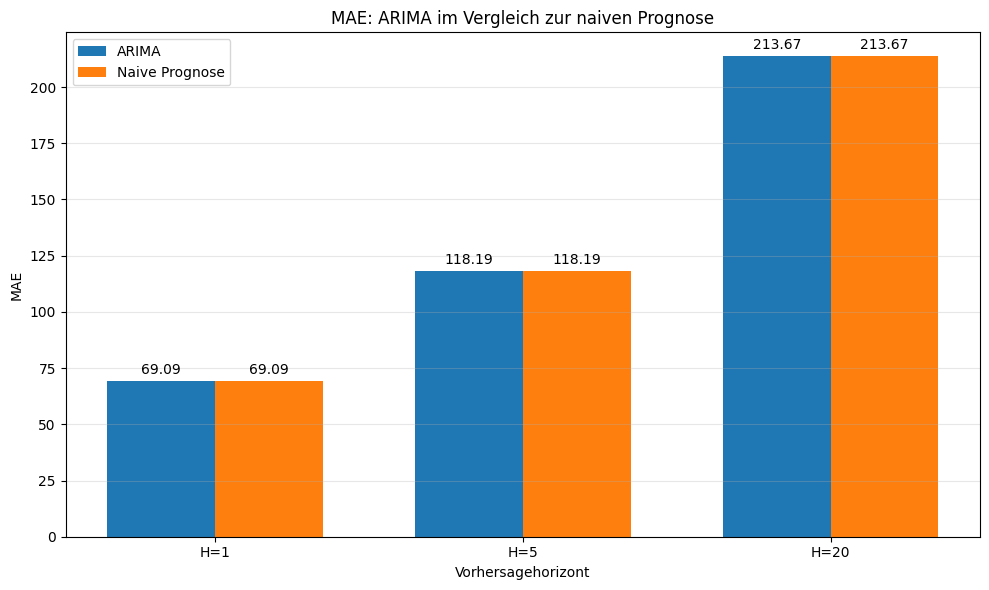

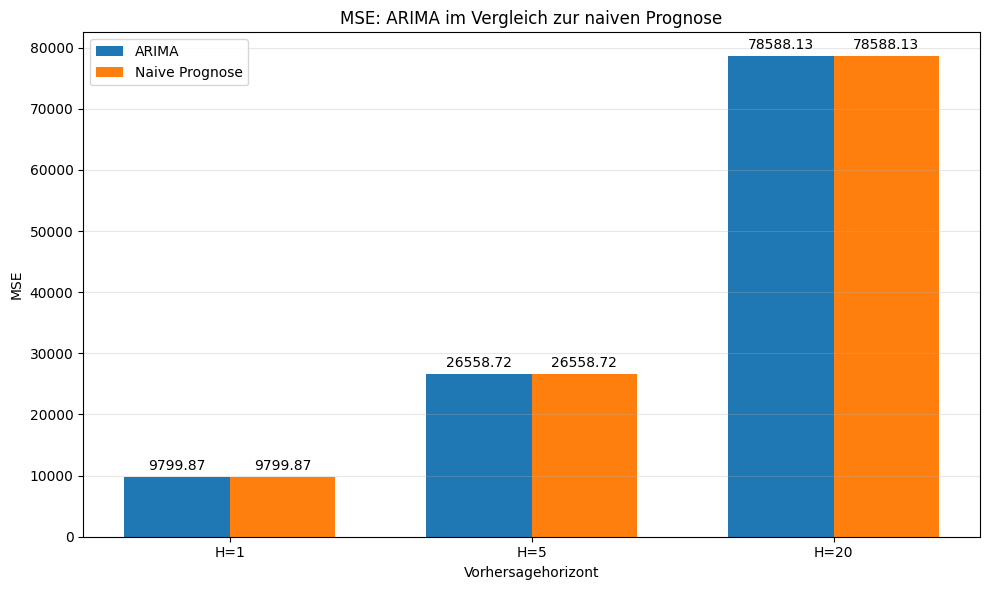

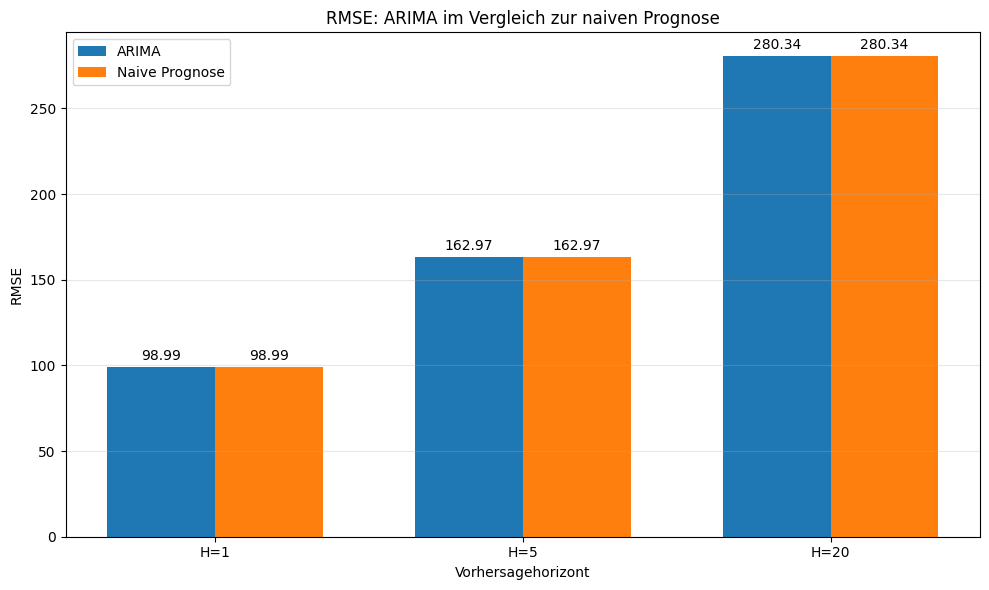

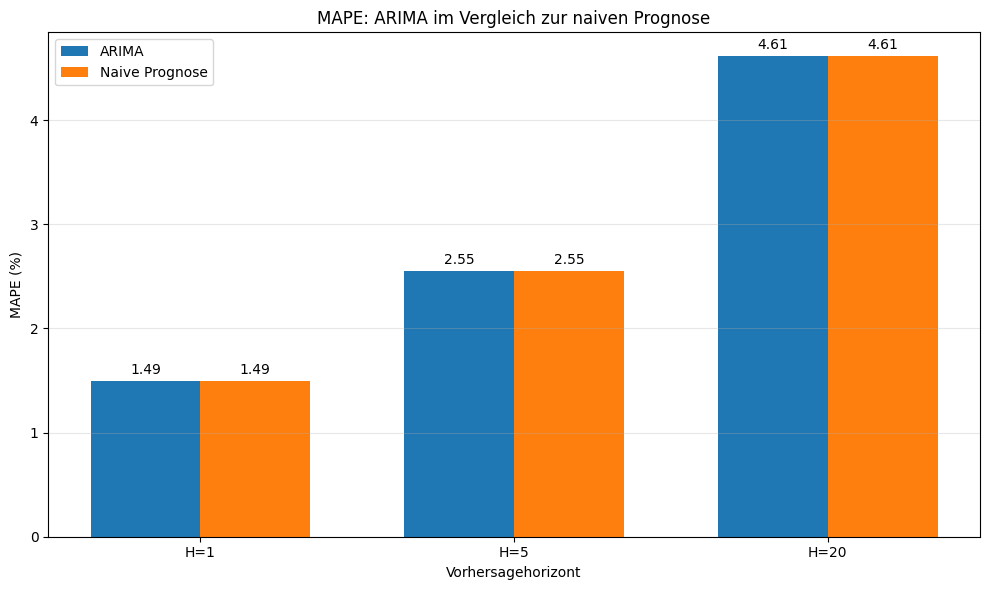

In [ ]:
def plot_metrics_by_horizon(test_results_df):
    """
    Erstellt pro Metrik ein Balkendiagramm.
    Auf der x-Achse stehen die Vorhersagehorizonte.
    ARIMA wird jeweils mit der naiven Prognose verglichen.
    """

    metrics = ["MAE", "MSE", "RMSE", "MAPE"]

    results = test_results_df.sort_values("horizon").copy()

    horizons = results["horizon"].astype(int).to_numpy()
    x = np.arange(len(horizons))
    width = 0.35

    for metric in metrics:

        arima_values = results[
            f"ARIMA_{metric}"
        ].to_numpy()

        naive_values = results[
            f"Naive_{metric}"
        ].to_numpy()

        plt.figure(figsize=(10, 6))

        arima_bars = plt.bar(
            x - width / 2,
            arima_values,
            width,
            label="ARIMA"
        )

        naive_bars = plt.bar(
            x + width / 2,
            naive_values,
            width,
            label="Naive Prognose"
        )

        plt.xticks(
            x,
            [f"H={h}" for h in horizons]
        )

        if metric == "MAPE":
            plt.ylabel("MAPE (%)")
        else:
            plt.ylabel(metric)

        plt.xlabel("Vorhersagehorizont")

        plt.title(
            f"{metric}: ARIMA im Vergleich zur naiven Prognose"
        )

        plt.legend()
        plt.grid(axis="y", alpha=0.3)

        plt.bar_label(
            arima_bars,
            fmt="%.2f",
            padding=3
        )

        plt.bar_label(
            naive_bars,
            fmt="%.2f",
            padding=3
        )

        plt.tight_layout()
        plt.show()


plot_metrics_by_horizon(test_results_df)